In [33]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df =pd.read_csv("C:/Users/DELL/Downloads/Data/archive (15)/Bank Customer Churn Prediction.csv")
df.head()

,customer_id,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,15634602,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,15647311,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,15619304,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,15701354,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,15737888,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [34]:
df.drop(['customer_id'], axis=1, inplace=True)
df.head()

,credit_score,country,gender,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [35]:
df = pd.get_dummies(df, drop_first=True).astype(int)
df.head(2)

,credit_score,age,tenure,balance,products_number,credit_card,active_member,estimated_salary,churn,country_Germany,country_Spain,gender_Male
0,619,42,2,0,1,1,1,101348,1,0,0,0
1,608,41,1,83807,1,0,1,112542,0,0,1,0


<Axes: >

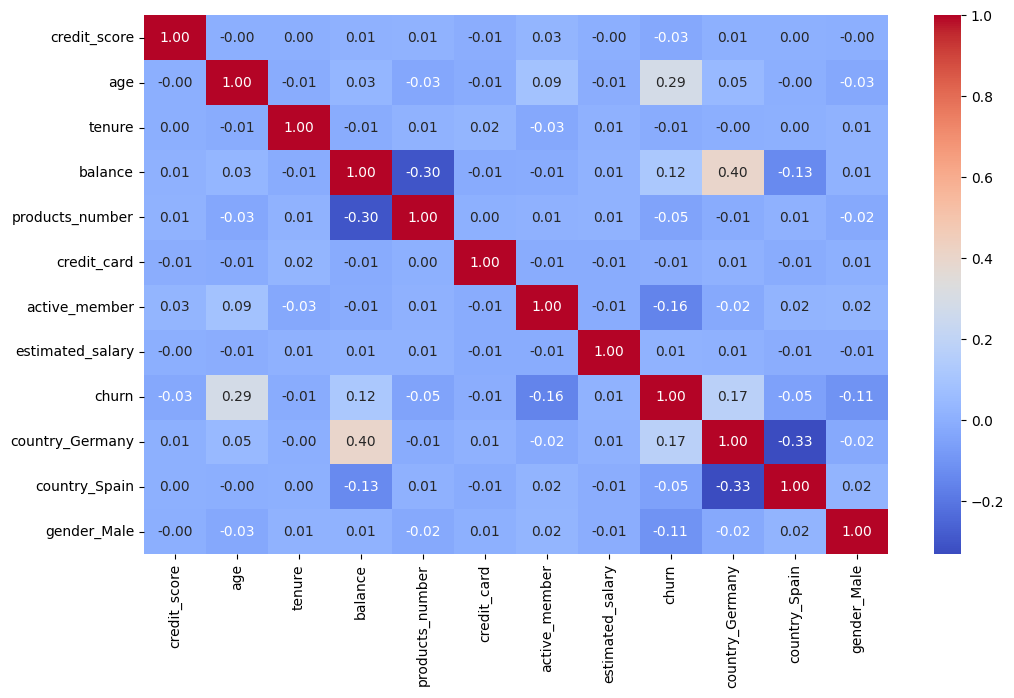

In [36]:
corr = df.corr()
plt.figure(figsize=(12,7))
sns.heatmap(corr, annot=True, fmt = '.2f', cmap = 'coolwarm')

In [37]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
credit_score,10000.0,650.5288,96.653299,350.0,584.00,652.0,718.00,850.0
age,10000.0,38.9218,10.487806,18.0,32.00,37.0,44.00,92.0
tenure,10000.0,5.0128,2.892174,0.0,3.00,5.0,7.00,10.0
balance,10000.0,76485.5715,62397.185107,0.0,0.00,97198.0,127643.75,250898.0
products_number,10000.0,1.5302,0.581654,1.0,1.00,1.0,2.00,4.0
credit_card,10000.0,0.7055,0.455840,0.0,0.00,1.0,1.00,1.0
active_member,10000.0,0.5151,0.499797,0.0,0.00,1.0,1.00,1.0
estimated_salary,10000.0,100089.7484,57510.491042,11.0,51001.75,100193.5,149387.75,199992.0
churn,10000.0,0.2037,0.402769,0.0,0.00,0.0,0.00,1.0
country_Germany,10000.0,0.2509,0.433553,0.0,0.00,0.0,1.00,1.0


In [38]:
## SCALING THE FEATURES(NORMALIZING)
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()

features = df.drop('churn', axis=1)
features_scaled = scaler.fit_transform(features)


In [39]:
from sklearn.model_selection import train_test_split

x = features_scaled
y = df['churn']

x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2 ,random_state=42)


In [40]:
df.shape

(10000, 12)

Classification Report:                precision    recall  f1-score   support

           0       0.83      0.96      0.89      1607
           1       0.55      0.20      0.29       393

    accuracy                           0.81      2000
   macro avg       0.69      0.58      0.59      2000
weighted avg       0.78      0.81      0.77      2000



<Axes: >

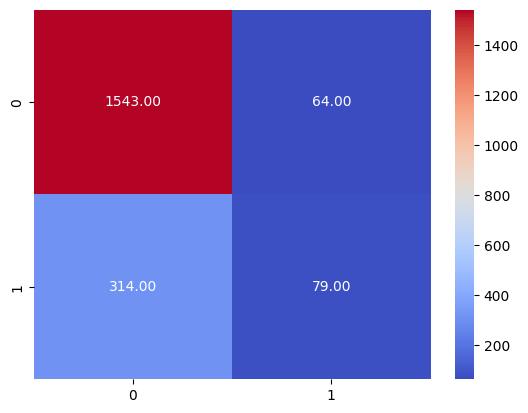

In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report

model= LogisticRegression()
model.fit(x_train, y_train)

y_pred = model.predict(x_test)


print('Classification Report: ', classification_report(y_test, y_pred))
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt = '.2f', cmap = 'coolwarm')



In [42]:
####################  REPORT #########
###### CLASSIFICATION REPORT
####ACCURACY
# This explains how many of the customers evaluated did the model correctly identify as either staying or leaving
# THe model was correct 81% of the time
#### PRECISION(Trust in predictions)
# This explains how correct the model actually is when it makes a prediction
# 83% of the time,the model makes the right predictions on staying customers and 60% on leaving customers
#### RECALL(Catching the leavers)
#The model correctly catches 17% of leavers and 97% of stayed customers
######F1-SCORE
# This gives a fair idea of how well we are identifying churn customers without too many false alarms




#########   CONFUSION MATRIX
# Correct and incorrect predictions
## STAYED
# Out of the 2000 customers, 1562 predicted to stay actually stayed, and 45 predicted to stay actually left
## LEFT
# 67 predicted to leave actually left and 326 predicted to leave actually stayed
